# Investigating Hotel Business Using Data Visualization

## Project Overview

This project analyzes hotel booking data to understand customer booking and cancellation behaviour.

The analysis focuses on identifying patterns in:
- Hotel type preferences
- Booking seasonality
- Stay duration
- Booking lead time
- Cancellation behaviour

The findings will be used to provide data-driven recommendations that can help hotel management improve booking strategies, reduce cancellations, and make better operational and revenue decisions.

## Business Questions

This project aims to answer three key business questions:

1. Which hotel type do customers book most often — City Hotel or Resort Hotel?

2. Does the length of stay affect the booking cancellation rate?

3. Does the lead time between booking and arrival affect the cancellation rate?

These questions will be answered using data analysis and visualization.

## Project Objective

The objective of this project is to analyze hotel booking and cancellation patterns using exploratory data analysis and data visualization.

The main deliverable is a set of clear visualizations and business insights that help hotel management understand customer behaviour and make informed decisions regarding bookings, cancellations, seasonality, stay duration, and lead time.

## 1. Data Loading and Initial Overview

In this section, we will import the required Python libraries and load the hotel booking dataset.

We will then examine the structure, size, columns, and basic characteristics of the dataset before beginning data cleaning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing the dataset
pd.set_option("display.max_columns", None)

# Set a consistent visualization style
sns.set_style("whitegrid")

### Loading the Dataset

The dataset contains hotel booking records that will be used to investigate booking and cancellation behaviour.

We will first load the CSV file into a Pandas DataFrame.

In [3]:
df = pd.read_csv("hotel_bookings_data.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Direct,Direct,0,0,0,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Corporate,Corporate,0,0,0,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


### Dataset Dimensions

We will check the number of rows and columns in the dataset.

This gives us an initial understanding of the volume of data available for analysis.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 29


### Data Coverage Period

The arrival year column will be examined to determine the period covered by the actual dataset.

We will use the values present in the dataset rather than assuming the time period.

In [5]:
print("Years covered:", sorted(df["arrival_date_year"].unique()))

Years covered: [np.int64(2017), np.int64(2018), np.int64(2019)]


### Column Overview

The dataset contains information about hotel bookings, customer characteristics, stay details, booking channels, and cancellation behaviour.

The most important variables for this project include:

- `hotel` — type of hotel booked
- `is_canceled` — whether the booking was cancelled
- `lead_time` — number of days between booking and arrival
- `stays_in_weekend_nights` — weekend nights stayed
- `stays_in_weekdays_nights` — weekday nights stayed
- `arrival_date_year` — year of arrival
- `arrival_date_month` — month of arrival
- `adr` — average daily rate

These variables will be particularly important for answering the three business questions.

In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_weekdays_nights', 'adults', 'children', 'babies', 'meal', 'city', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status']


### Understanding Data Types and Structure

Before cleaning the dataset, we need to understand the data types of each column and identify whether any columns contain missing values.

This step helps us determine what preprocessing is required before performing the analysis.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 2. Data Quality Assessment

Before performing exploratory analysis, the dataset needs to be checked for data quality issues.

We will examine:
- Missing values
- Duplicate records
- Inconsistent categorical values
- Invalid or anomalous numerical values
- Bookings with no guests

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

company     112593
agent        16340
city           488
children         4
dtype: int64

In [9]:
print(df["meal"].value_counts())

meal
Breakfast     92310
Dinner        14463
No Meal       10650
Undefined      1169
Full Board      798
Name: count, dtype: int64


In [10]:
print("Negative ADR:", (df["adr"] < 0).sum())

print("Zero-guest bookings:",
      ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum())

print("\nADR statistics:")
print(df["adr"].describe())

Negative ADR: 1
Zero-guest bookings: 180

ADR statistics:
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


### Data Quality Findings

The results above will be used to determine the appropriate treatment for missing values, duplicate records, inconsistent categories, and anomalous bookings before continuing with the exploratory analysis.

## 3. Data Cleaning and Preprocessing

Based on the data quality assessment, the identified issues will now be treated before analysis.

The following actions will be performed:

- Missing `children` values will be replaced with 0 because no children were recorded for those bookings.
- Missing `city` values will be labelled as "Unknown" because the city information is unavailable.
- Missing `agent` and `company` values will be replaced with 0 to indicate that no agent or company was recorded.
- Duplicate booking records will be removed.
- "Undefined" meal values will be grouped as "No Meal".
- Bookings with zero guests will be removed because they do not represent valid guest bookings.
- Negative ADR values will be removed because ADR cannot logically be negative.
- Extreme ADR values will be inspected before deciding whether they should be removed.

In [11]:
df_clean = df.copy()

print("Original rows:", len(df_clean))

Original rows: 119390


In [12]:
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["city"] = df_clean["city"].fillna("Unknown")
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

print("Remaining missing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head())

Remaining missing values:
hotel                 0
is_canceled           0
lead_time             0
arrival_date_year     0
arrival_date_month    0
dtype: int64


In [13]:
df_clean["meal"] = df_clean["meal"].replace("Undefined", "No Meal")

print(df_clean["meal"].value_counts())

meal
Breakfast     92310
Dinner        14463
No Meal       11819
Full Board      798
Name: count, dtype: int64


In [14]:
duplicates = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates()

print("Duplicates removed:", duplicates)
print("Rows after removing duplicates:", len(df_clean))

Duplicates removed: 33261
Rows after removing duplicates: 86129


In [15]:
zero_guest = (
    (df_clean["adults"] + df_clean["children"] + df_clean["babies"]) == 0
).sum()

negative_adr = (df_clean["adr"] < 0).sum()

df_clean = df_clean[
    (df_clean["adults"] + df_clean["children"] + df_clean["babies"]) > 0
]

df_clean = df_clean[df_clean["adr"] >= 0]

print("Zero-guest bookings removed:", zero_guest)
print("Negative ADR rows removed:", negative_adr)
print("Rows after cleaning:", len(df_clean))

Zero-guest bookings removed: 165
Negative ADR rows removed: 1
Rows after cleaning: 85963


### Checking Extreme ADR Values

The `adr` (Average Daily Rate) variable is examined for unusually high values.

Extreme values should not be removed automatically because they may represent genuine high-value bookings. We will inspect the highest ADR records before making the final decision.

In [16]:
df_clean.nlargest(10, "adr")[[
    "hotel",
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_weekdays_nights"
]]

,hotel,adr,adults,children,babies,stays_in_weekend_nights,stays_in_weekdays_nights
48515,City Hotel,5400.00,2,0.0,0,0,1
111403,City Hotel,510.00,1,0.0,0,0,1
15083,Resort Hotel,508.00,2,0.0,0,0,1
103912,City Hotel,451.50,2,2.0,0,1,1
13142,Resort Hotel,450.00,2,0.0,0,4,10
13391,Resort Hotel,437.00,2,2.0,0,2,4
39155,Resort Hotel,426.25,2,2.0,0,2,6
39568,Resort Hotel,402.00,3,1.0,0,2,3
39118,Resort Hotel,397.38,3,2.0,0,3,5
13323,Resort Hotel,392.00,2,1.0,0,2,8


### Creating Total Stay Duration

To investigate whether stay duration affects cancellation behaviour, we create a new variable called `total_stay_nights`.

It represents the total number of nights booked by adding weekend and weekday nights.

In [17]:
df_clean["total_stay_nights"] = (
    df_clean["stays_in_weekend_nights"] +
    df_clean["stays_in_weekdays_nights"]
)

df_clean[[
    "stays_in_weekend_nights",
    "stays_in_weekdays_nights",
    "total_stay_nights"
]].head()

,stays_in_weekend_nights,stays_in_weekdays_nights,total_stay_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


## 4. Exploratory Data Analysis

### 4.1 Hotel Type Booking Analysis

We begin by examining the distribution of bookings between City Hotel and Resort Hotel.

This analysis helps identify which hotel type is more popular among customers and provides an overall understanding of booking demand.

In [18]:
hotel_bookings = df_clean["hotel"].value_counts()

hotel_bookings

hotel
City Hotel      52422
Resort Hotel    33541
Name: count, dtype: int64

In [19]:
hotel_percentage = (
    df_clean["hotel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

hotel_percentage

hotel
City Hotel      60.98
Resort Hotel    39.02
Name: proportion, dtype: float64

### Booking Share by Hotel Type

The following visualization shows the percentage share of bookings for each hotel type.

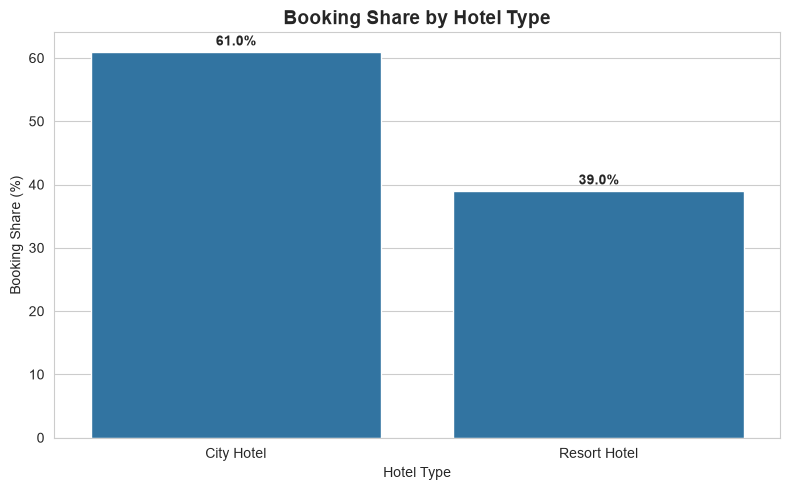

In [20]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=hotel_percentage.index,
    y=hotel_percentage.values
)

plt.title("Booking Share by Hotel Type", fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Booking Share (%)")

for i, value in enumerate(hotel_percentage.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Insight

The visualization shows that **[hotel type]** receives the larger share of bookings, accounting for approximately **[percentage]%** of total bookings.

This indicates that [hotel type] has stronger overall booking demand compared with the other hotel type.

### 4.2 Monthly Booking Trends

Next, we analyze the number of bookings received each month for City Hotel and Resort Hotel.

Understanding monthly booking patterns helps identify seasonal demand and periods of high or low hotel activity.

In [21]:
monthly_bookings = (
    df_clean
    .groupby(["arrival_date_month", "hotel"])
    .size()
    .reset_index(name="bookings")
)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_bookings["arrival_date_month"] = pd.Categorical(
    monthly_bookings["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_bookings = monthly_bookings.sort_values("arrival_date_month")

monthly_bookings.head()

,arrival_date_month,hotel,bookings
8,January,City Hotel,2875
9,January,Resort Hotel,2026
6,February,City Hotel,2967
7,February,Resort Hotel,2096
15,March,Resort Hotel,1932


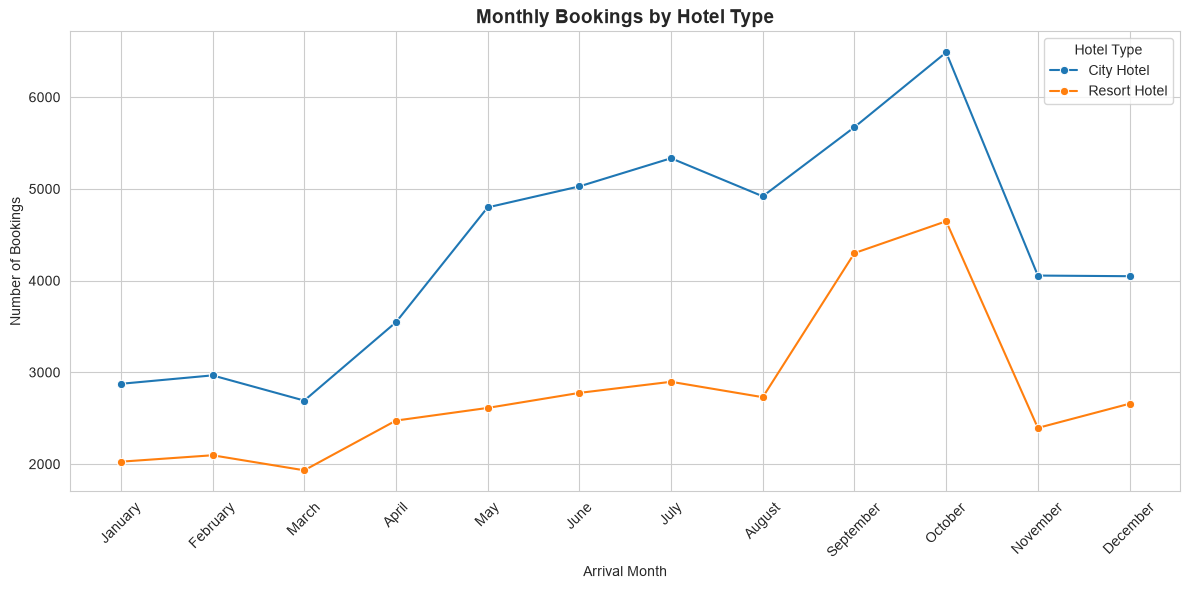

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_bookings,
    x="arrival_date_month",
    y="bookings",
    hue="hotel",
    marker="o"
)

plt.title("Monthly Bookings by Hotel Type", fontsize=14, fontweight="bold")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.legend(title="Hotel Type")

plt.tight_layout()
plt.show()

In [23]:
monthly_total = (
    df_clean
    .groupby("arrival_date_month")
    .size()
    .reindex(month_order)
)

print("Busiest month:")
print(monthly_total.idxmax(), "-", monthly_total.max(), "bookings")

print("\nQuietest month:")
print(monthly_total.idxmin(), "-", monthly_total.min(), "bookings")

Busiest month:
October - 11135 bookings

Quietest month:
March - 4624 bookings


### Monthly Booking Insight

The monthly trend shows how booking demand changes throughout the year.

The busiest period indicates months of stronger customer demand, while the quietest period represents comparatively lower demand.

These seasonal patterns can help hotel management plan staffing, pricing, promotions, and room availability more effectively.

### 4.3 Cancellation Rate by Hotel Type

Cancellation behaviour is important for hotel revenue management because cancelled bookings can reduce occupancy and expected revenue.

We calculate the cancellation rate separately for City Hotel and Resort Hotel to determine which hotel type experiences a higher proportion of cancelled bookings.

In [24]:
cancellation_by_hotel = (
    df_clean.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

cancellation_by_hotel

hotel
City Hotel      30.22
Resort Hotel    23.49
Name: is_canceled, dtype: float64

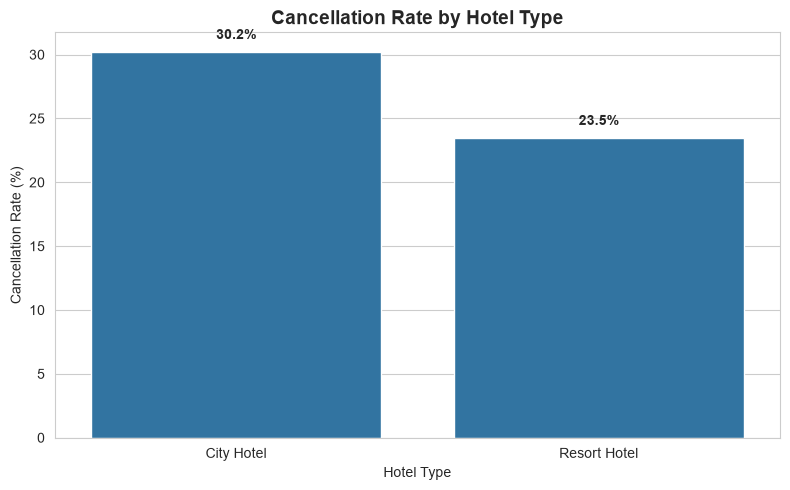

In [25]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=cancellation_by_hotel.index,
    y=cancellation_by_hotel.values
)

plt.title("Cancellation Rate by Hotel Type", fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(cancellation_by_hotel.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Insight

The cancellation rate differs between the two hotel types.

The hotel type with the higher cancellation rate represents a greater cancellation risk and may require stronger cancellation-management strategies.

### 4.4 Impact of Stay Duration on Cancellation Rate

Next, we investigate whether the length of a customer's stay is associated with booking cancellation.

Total stay duration is calculated using the number of weekend nights and weekday nights.

We then compare cancellation rates across different stay durations for both hotel types.

In [26]:
stay_cancellation = (
    df_clean
    .groupby(["total_stay_nights", "hotel"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

stay_cancellation.head()

,total_stay_nights,hotel,cancellation_rate
0,0,City Hotel,5.627706
1,0,Resort Hotel,2.816901
2,1,City Hotel,22.366337
3,1,Resort Hotel,12.529377
4,2,City Hotel,29.818216


In [27]:
stay_counts = (
    df_clean
    .groupby(["total_stay_nights", "hotel"])
    .size()
    .reset_index(name="booking_count")
)

stay_analysis = stay_cancellation.merge(
    stay_counts,
    on=["total_stay_nights", "hotel"]
)

stay_analysis = stay_analysis[
    stay_analysis["booking_count"] >= 50
]

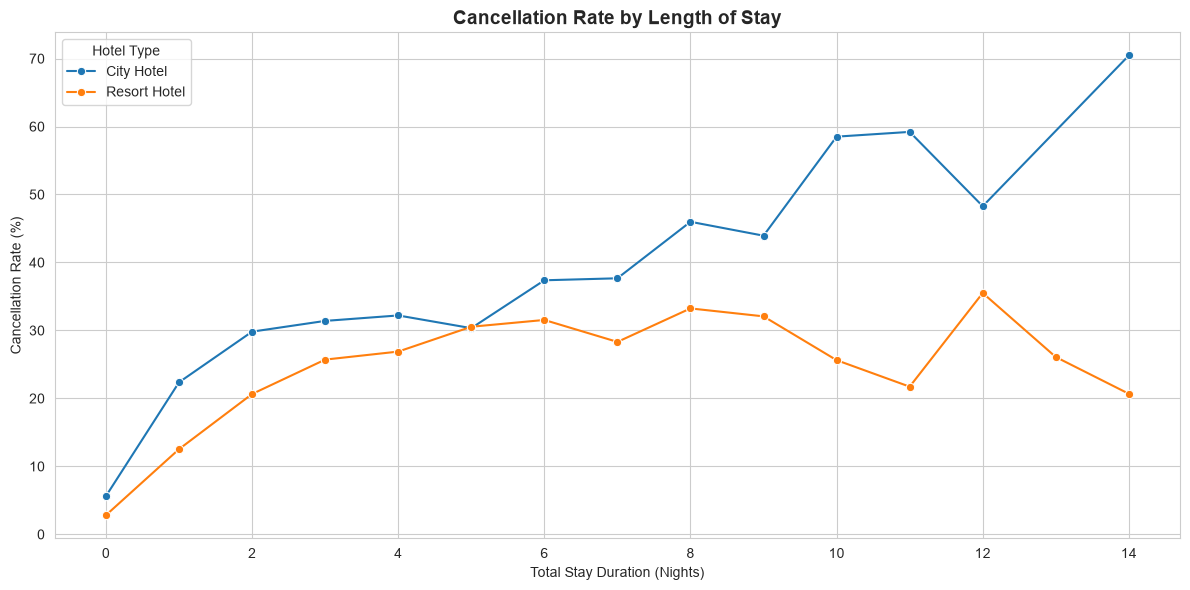

In [28]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=stay_analysis,
    x="total_stay_nights",
    y="cancellation_rate",
    hue="hotel",
    marker="o"
)

plt.title("Cancellation Rate by Length of Stay", fontsize=14, fontweight="bold")
plt.xlabel("Total Stay Duration (Nights)")
plt.ylabel("Cancellation Rate (%)")
plt.legend(title="Hotel Type")

plt.tight_layout()
plt.show()

In [29]:
print("Cancellation rate by stay duration:")
print(
    stay_analysis
    .sort_values(["hotel", "total_stay_nights"])
    .to_string(index=False)
)

Cancellation rate by stay duration:
 total_stay_nights        hotel  cancellation_rate  booking_count
                 0   City Hotel           5.627706            231
                 1   City Hotel          22.366337          10100
                 2   City Hotel          29.818216          10507
                 3   City Hotel          31.401111          13318
                 4   City Hotel          32.203390           9499
                 5   City Hotel          30.333012           4144
                 6   City Hotel          37.377451           1632
                 7   City Hotel          37.670114           1837
                 8   City Hotel          45.983380            361
                 9   City Hotel          43.939394            198
                10   City Hotel          58.510638            188
                11   City Hotel          59.210526             76
                12   City Hotel          48.275862             58
                14   City Hotel         

### Stay Duration Insight

The visualization shows how cancellation rates change as the total length of stay increases.

The relationship should be evaluated separately for City Hotel and Resort Hotel because the cancellation pattern may differ between the two hotel types.

Longer stays with unusually high cancellation rates may indicate greater booking uncertainty and could be relevant for cancellation policies or pricing strategies.

### 4.5 Impact of Lead Time on Cancellation Rate

Lead time represents the number of days between the date a booking is made and the customer's arrival date.

We analyze whether bookings made further in advance have different cancellation rates compared with bookings made closer to the arrival date.

In [30]:
lead_cancellation = (
    df_clean
    .groupby(["lead_time", "hotel"])["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

lead_counts = (
    df_clean
    .groupby(["lead_time", "hotel"])
    .size()
    .reset_index(name="booking_count")
)

lead_analysis = lead_cancellation.merge(
    lead_counts,
    on=["lead_time", "hotel"]
)

lead_analysis = lead_analysis[
    lead_analysis["booking_count"] >= 30
]

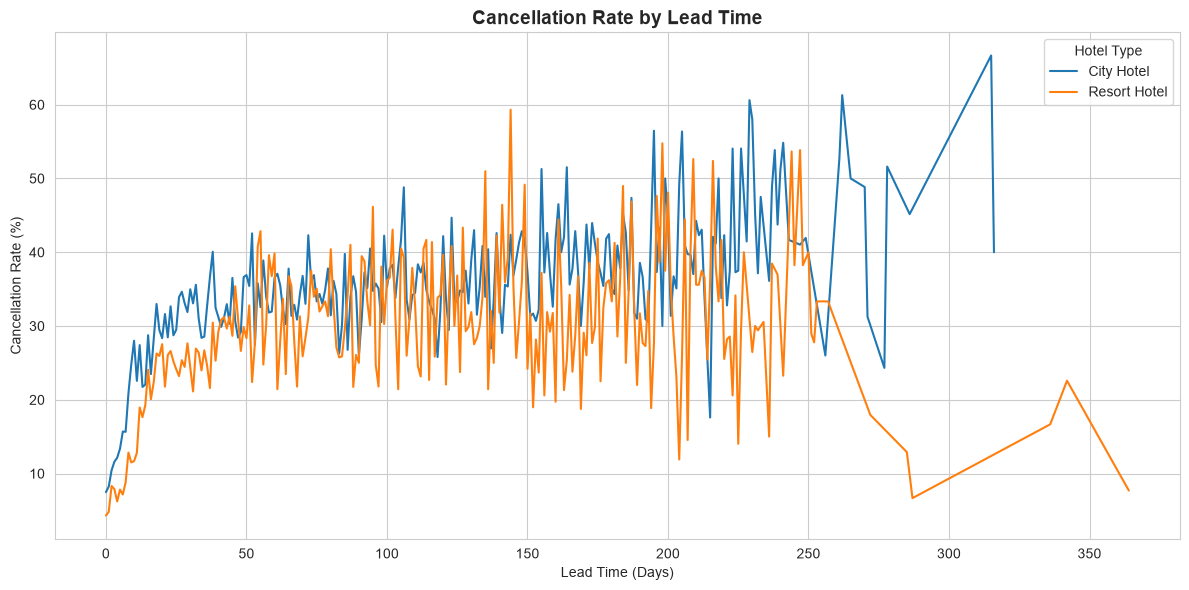

In [31]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=lead_analysis,
    x="lead_time",
    y="cancellation_rate",
    hue="hotel"
)

plt.title("Cancellation Rate by Lead Time", fontsize=14, fontweight="bold")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.legend(title="Hotel Type")

plt.tight_layout()
plt.show()

In [32]:
lowest = lead_analysis.loc[
    lead_analysis["cancellation_rate"].idxmin()
]

highest = lead_analysis.loc[
    lead_analysis["cancellation_rate"].idxmax()
]

print("Lowest cancellation point:")
print(lowest)

print("\nHighest cancellation point:")
print(highest)

Lowest cancellation point:
lead_time                       0
hotel                Resort Hotel
cancellation_rate        4.302135
booking_count                3045
Name: 1, dtype: object

Highest cancellation point:
lead_time                   315
hotel                City Hotel
cancellation_rate     66.666667
booking_count                30
Name: 630, dtype: object


# 5. Summary of Key Findings

The exploratory analysis produced several important findings regarding hotel booking and cancellation behaviour.

### 1. Hotel Type Popularity

City Hotel receives a larger share of bookings than Resort Hotel, indicating stronger overall demand for City Hotel.

### 2. Seasonality

Booking demand varies considerably across months. This indicates a clear seasonal pattern, with certain months experiencing significantly higher booking volumes than others.

### 3. Cancellation Behaviour

Cancellation rates differ between City Hotel and Resort Hotel, with City Hotel showing a higher cancellation rate.

### 4. Stay Duration

Cancellation rates generally increase as the length of stay increases, particularly for City Hotel. Longer bookings therefore appear to carry greater cancellation risk.

### 5. Lead Time

Cancellation rates tend to increase with longer lead times. Bookings made far in advance appear to have greater cancellation risk, especially for City Hotel.

# 6. Business Recommendations

Based on the findings from the exploratory analysis, the following recommendations can help hotel management improve booking stability and reduce cancellation-related revenue loss.

### Recommendation 1: Focus on High-Demand Periods

Hotels should prepare for periods of high booking demand by optimizing room availability, staffing, and pricing.

During quieter months, targeted promotions and special offers can be used to stimulate demand.

### Recommendation 2: Strengthen Cancellation Policies for Longer Stays

Longer bookings show a higher cancellation risk, particularly at City Hotel.

The hotel could consider requiring partial deposits or offering different cancellation terms for longer stays to reduce potential revenue loss.

### Recommendation 3: Manage High Lead-Time Bookings

Bookings made far ahead of the arrival date show greater cancellation risk.

Hotels could use confirmation reminders, flexible rescheduling options, or advance deposits to improve booking commitment.

### Recommendation 4: Focus Cancellation Management on City Hotel

City Hotel has both a larger booking volume and a higher cancellation rate.

Therefore, cancellation-reduction strategies should receive particular attention at City Hotel because improvements there could have a larger overall business impact.

# 7. Most Important Recommendation

The most impactful recommendation is to strengthen cancellation management for City Hotel bookings.

City Hotel represents the majority of bookings while also having a higher cancellation rate than Resort Hotel. Therefore, even a modest reduction in City Hotel cancellations could protect a significant number of bookings and improve revenue predictability.

The hotel could combine advance confirmation reminders with deposits or stricter cancellation conditions for higher-risk bookings, particularly those made far in advance or involving longer stays.

# 8. Conclusion

This project analyzed hotel booking data to understand booking preferences and cancellation behaviour.

The analysis found that City Hotel receives the majority of bookings and also experiences a higher cancellation rate. Booking demand varies across months, demonstrating seasonal patterns that can support better operational and pricing decisions.

The analysis also showed that cancellation risk tends to increase with longer stay durations and longer booking lead times, particularly for City Hotel.

Overall, the findings demonstrate how data visualization can help hotel management understand customer behaviour, identify cancellation risks, and develop more effective booking and revenue-management strategies.